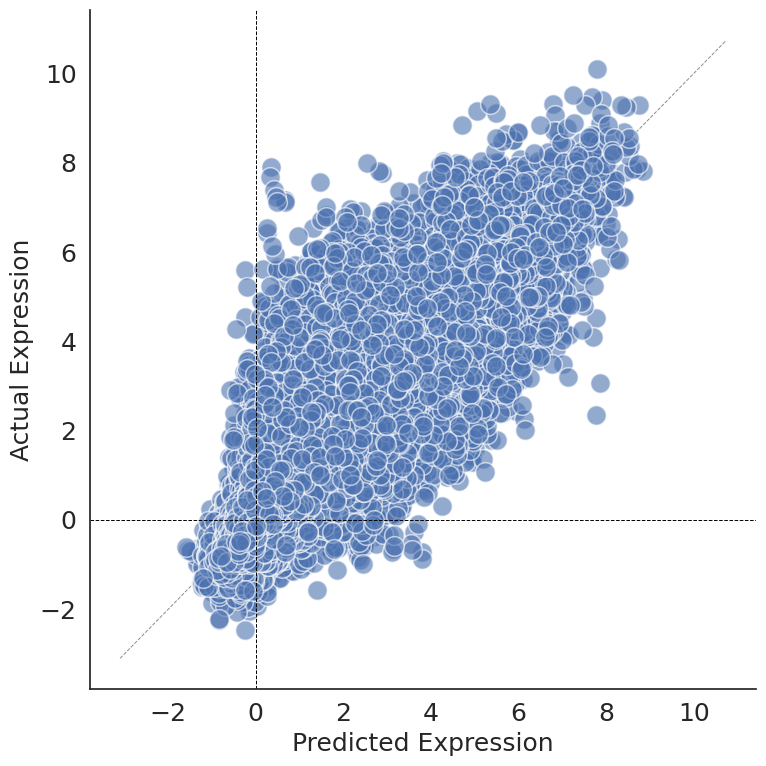

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import pandas as pd

# Set Seaborn style
sns.set(style="white")
plt.rcParams['svg.fonttype'] = 'none'  # Keep text as text
plt.rcParams['path.simplify'] = False  # Don't simplify paths
# plt.rcParams['font.family'] = 'Calibri'
plt.rcParams['font.size'] = 18
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
# Load data
prediction = pd.read_csv(
    "/scratch/st-cdeboer-1/sambina/mpra/output/chromosome/gosai/output_lfcse/output_k562/fold_4/predicted_expression.txt",
    sep="\t"
)

actual = pd.read_csv(
    "/scratch/st-cdeboer-1/sambina/mpra/data/chromosome/gosai/data_lfcse/data_k562/fold_4/test.txt.gz",
    sep="\t",
    compression='gzip'
)

# Merge on seq_id
merged_df = pd.merge(prediction, actual, on='seq_id')

# Remove any rows with NaN
merged_df = merged_df[['dream_rnn_prediction', 'mean_value']].dropna()

# Calculate correlation
r, _ = pearsonr(merged_df['dream_rnn_prediction'], merged_df['mean_value'])
r2 = r
n_points = len(merged_df)

# Create plot
fig, ax = plt.subplots(figsize=(8, 8))

# Scatterplot
sns.scatterplot(
    x=merged_df['dream_rnn_prediction'], 
    y=merged_df['mean_value'], 
    ax=ax,
    color="#4C72B0",  
    s=200, 
    alpha=0.6,
    rasterized=True
)

# Reference lines
ax.axhline(0, color='black', linestyle='--', linewidth=0.7)
ax.axvline(0, color='black', linestyle='--', linewidth=0.7)

# Add diagonal reference line (y=x)
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1])
]
ax.plot(lims, lims, 'k--', alpha=0.5, linewidth=0.7, zorder=0)


# Labels
ax.set_xlabel('Predicted Expression')
ax.set_ylabel('Actual Expression')

# Aesthetic tweaks
# ax.grid(True, linestyle=':', alpha=0.3)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/2-opentargets_model_variant_effect/gosai/predicted_vs_actual_scatter.svg", 
    format="svg"
)
plt.show()